# Diffusion Maps, Lafon2006
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### About this doc 

`-` reference

Lafon, S., & Lee, A. B. (2006). Diffusion maps and coarse-graining: A unified framework for dimensionality reduction, graph partitioning, and data set parameterization. IEEE transactions on pattern analysis and machine intelligence, 28(9), 1393-1403.

Nadler, B., Lafon, S., Coifman, R. R., & Kevrekidis, I. G. (2006). Diffusion maps, spectral clustering and reaction coordinates of dynamical systems. Applied and Computational Harmonic Analysis, 21(1), 113-127.

Coifman, R. R., & Lafon, S. (2006). Diffusion maps. Applied and computational harmonic analysis, 21(1), 5-30.

### Notations

`-` $\Omega=\{x_1,x_2,\dots,x_n\}=$ a data set of points

`-` $w(x,y)=$ weight function

`-` $G=(\Omega,W)$ 

`-` $p_1(x,y)=\frac{w(x,y)}{\sum_{z \in \Omega}w(x,z)}=\frac{w(x,y)}{d(x)}$probability of going from point $x$ to $y$ in one step 

`-` $d(x)=\sum_{z\in \Omega}w(x,z)=$ out-degree 

`-` $\phi_0(x)=\frac{d(x)}{\sum_{z\in \Omega}d(z)}$

`-` $p_t(x,\cdot)$

### Basic Thm

`-` (에르고드성) 그래프가 연결되어 있다면 아래가 성립한다. 

$$\lim_{t \to \infty }p_t(x,y)=\phi_0(y)$$

### Point 

In [82]:
import requests
exec(requests.get('https://raw.githubusercontent.com/miruetoto/miruetoto.github.io/master/source/pybase.py').text)
import matplotlib.cm as cm

R[write to console]: Loading required package: usethis

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

R[write to console]: ✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.0.6     ✔ dplyr   1.0.6
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



In [83]:
np.random.seed(777)
pi=math.pi
n=59
ang=np.linspace(-pi,pi-2*pi/n,n)
V=np.arange(n)+1
r=1
vx=r*np.cos(ang)
vy=r*np.sin(ang)
f1=vx*0
f2=vx*0
f2[vy<0]=3+np.random.normal(size=sum(vy<0),scale=0.1)
f2[vy>0]= -3+np.random.normal(size=sum(vy>0),scale=0.1)

In [84]:
Sigma=l2distance(np.matrix([vx,vy]).T)

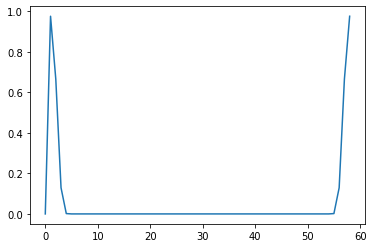

In [31]:
# Edg setting
Sigma=sigmamat(np.matrix([vx,vy]).T)
W=weightmat(Sigma,theta=0.05); 
E=W>0
plt.plot(W[0,:].T)
# color
col=list(np.array(cm.rainbow((ang+pi)/2/pi)))

In [32]:
W

array([[0.00000000e+00, 9.74651224e-01, 6.64656154e-01, ...,
        1.28930520e-01, 6.64656154e-01, 9.74651224e-01],
       [9.74651224e-01, 0.00000000e+00, 9.74651224e-01, ...,
        1.68007800e-03, 1.28930520e-01, 6.64656154e-01],
       [6.64656154e-01, 9.74651224e-01, 0.00000000e+00, ...,
        2.19082404e-07, 1.68007800e-03, 1.28930520e-01],
       ...,
       [1.28930520e-01, 1.68007800e-03, 2.19082404e-07, ...,
        0.00000000e+00, 9.74651224e-01, 6.64656154e-01],
       [6.64656154e-01, 1.28930520e-01, 1.68007800e-03, ...,
        9.74651224e-01, 0.00000000e+00, 9.74651224e-01],
       [9.74651224e-01, 6.64656154e-01, 1.28930520e-01, ...,
        6.64656154e-01, 9.74651224e-01, 0.00000000e+00]])

In [36]:
W.round(3).sum(axis=0)

array([3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542, 3.542,
       3.542, 3.542, 3.542, 3.542, 3.542])

In [40]:
P=W/3.542

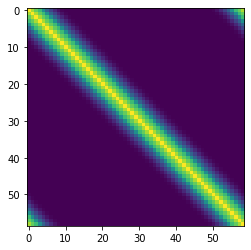

In [51]:
plt.imshow(P@P@P@P)

In [52]:
P4=P@P@P@P

In [62]:
sum((P4[0,:]-P4[1,:])**2)

0.003946624840501635